In [1]:
import pandas as pd

df = pd.read_csv("Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Num
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.5,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [ ]:

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'].fillna(0, inplace=True)


df['Churn_Num'] = df['Churn'].apply(lambda x: 1 if x == "Yes" else 0)

df.head()

C:\Users\alekh\AppData\Local\Temp\ipykernel_13568\1949284255.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Num
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [3]:
churn_rate = df['Churn_Num'].mean() * 100
print("Churn Rate:", churn_rate)

Churn Rate: 26.536987079369588


In [4]:
df.groupby('PaymentMethod')['Churn_Num'].mean() * 100

PaymentMethod
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Churn_Num, dtype: float64

In [6]:
df.groupby('InternetService')['Churn_Num'].mean() * 100

InternetService
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn_Num, dtype: float64

In [7]:
df.groupby('TechSupport')['Churn_Num'].mean() * 100

TechSupport
No                     41.635474
No internet service     7.404980
Yes                    15.166341
Name: Churn_Num, dtype: float64

In [8]:
df['tenure'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [9]:
df.groupby('tenure')['Churn_Num'].mean()

tenure
0     0.000000
1     0.619902
2     0.516807
3     0.470000
4     0.471591
        ...   
68    0.090000
69    0.084211
70    0.092437
71    0.035294
72    0.016575
Name: Churn_Num, Length: 73, dtype: float64

In [ ]:

df['tenure_group'] = pd.cut(df['tenure'],
                           bins=[0,12,24,48,72],
                           labels=['0-12','12-24','24-48','48+'])

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Num,tenure_group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-12
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,0,24-48
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0-12
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,24-48
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-12


In [11]:
df.groupby('tenure_group')['Churn_Num'].mean() * 100

C:\Users\alekh\AppData\Local\Temp\ipykernel_13568\717738813.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('tenure_group')['Churn_Num'].mean() * 100


tenure_group
0-12     47.678161
12-24    28.710938
24-48    20.388959
48+       9.513176
Name: Churn_Num, dtype: float64

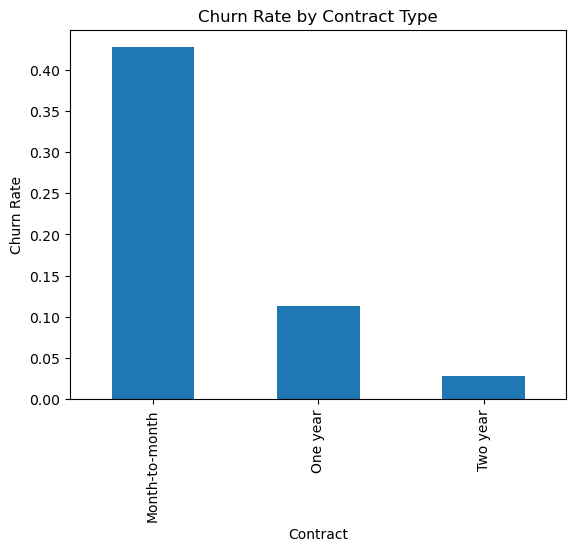

In [12]:
import matplotlib.pyplot as plt

df.groupby('Contract')['Churn_Num'].mean().plot(kind='bar')
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xlabel("Contract")
plt.show()

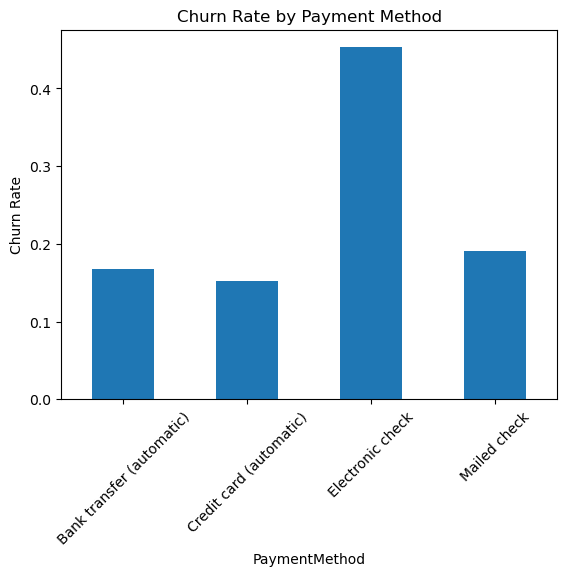

In [13]:
df.groupby('PaymentMethod')['Churn_Num'].mean().plot(kind='bar')
plt.title("Churn Rate by Payment Method")
plt.ylabel("Churn Rate")
plt.xticks(rotation=45)
plt.show()

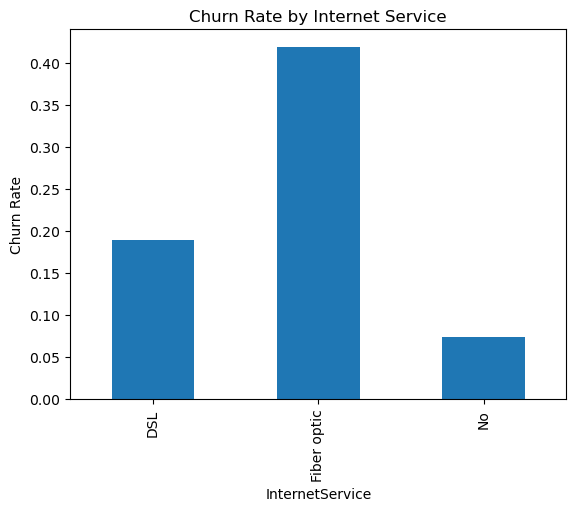

In [14]:
df.groupby('InternetService')['Churn_Num'].mean().plot(kind='bar')
plt.title("Churn Rate by Internet Service")
plt.ylabel("Churn Rate")
plt.show()

C:\Users\alekh\AppData\Local\Temp\ipykernel_13568\3303105381.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('tenure_group')['Churn_Num'].mean().plot(kind='bar')


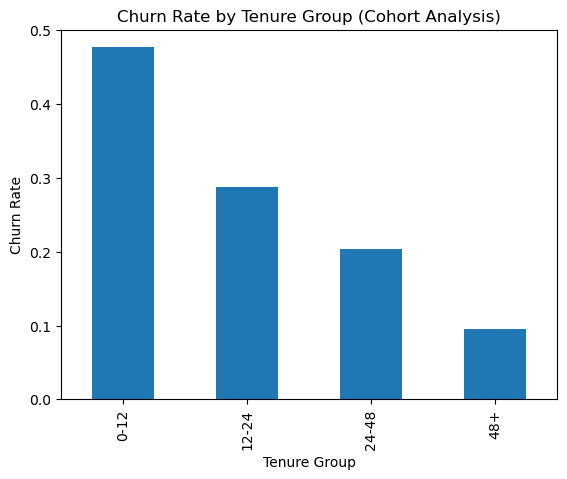

In [15]:
df.groupby('tenure_group')['Churn_Num'].mean().plot(kind='bar')
plt.title("Churn Rate by Tenure Group (Cohort Analysis)")
plt.ylabel("Churn Rate")
plt.xlabel("Tenure Group")
plt.show()

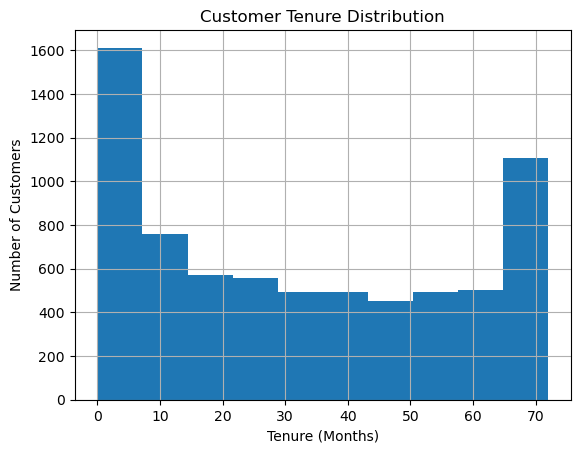

In [16]:
df['tenure'].hist()
plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()